In [1]:
import os
import shutil
import random
from pathlib import Path

# Pfade anpassen (hier liegt dein Datensatz)
source_base = Path("PlantVillage")
target_base = Path("dataset")  # Hierhin wird neu aufgeteilt

# Zufall festlegen (damit Split reproduzierbar ist)
random.seed(42)

# Split-Verhältnis
train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

# Alle Klassenordner (z. B. Tomato_healthy, Potato___Late_blight ...)
classes = [d for d in os.listdir(source_base) if (source_base / d).is_dir()]

for cls in classes:
    src_dir = source_base / cls
    imgs = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random.shuffle(imgs)

    n = len(imgs)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)

    splits = {
        "train": imgs[:n_train],
        "val":   imgs[n_train:n_train + n_val],
        "test":  imgs[n_train + n_val:]
    }

    for split_name, files in splits.items():
        dest_dir = target_base / split_name / cls
        dest_dir.mkdir(parents=True, exist_ok=True)
        for fname in files:
            shutil.copy(src_dir / fname, dest_dir / fname)

    print(f"{cls:35s} → train: {len(splits['train'])}, val: {len(splits['val'])}, test: {len(splits['test'])}")

print("\n✅ Split abgeschlossen! Neue Struktur liegt in 'dataset/'")


Tomato_healthy                      → train: 1113, val: 238, test: 240
Potato___Early_blight               → train: 700, val: 150, test: 150
PlantVillage                        → train: 0, val: 0, test: 0
Tomato__Tomato_YellowLeaf__Curl_Virus → train: 2245, val: 481, test: 482
Tomato_Early_blight                 → train: 700, val: 150, test: 150
Tomato__Target_Spot                 → train: 982, val: 210, test: 212
Potato___Late_blight                → train: 700, val: 150, test: 150
Tomato_Leaf_Mold                    → train: 666, val: 142, test: 144
Tomato_Spider_mites_Two_spotted_spider_mite → train: 1173, val: 251, test: 252
Tomato_Septoria_leaf_spot           → train: 1239, val: 265, test: 267
Tomato__Tomato_mosaic_virus         → train: 261, val: 55, test: 57
Pepper__bell___Bacterial_spot       → train: 697, val: 149, test: 151
Tomato_Bacterial_spot               → train: 1488, val: 319, test: 320
Tomato_Late_blight                  → train: 1336, val: 286, test: 287
Pepper__bell

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pathlib

# --- Pfade anpassen ---
train_dir = pathlib.Path("dataset/train")   # ggf. ändern auf dataset_combined/train
val_dir   = pathlib.Path("dataset/val")

# --- Basisparameter ---
img_size = (224, 224)
batch_size = 32

# --- Dataset laden & Label anpassen (healthy = 0, alle anderen = 1) ---
def preprocess_dataset(directory):
    ds = keras.utils.image_dataset_from_directory(
        directory,
        image_size=img_size,
        batch_size=batch_size,
    )

    def relabel(x, y):
        class_names = ds.class_names
        # alle Ordner, die "healthy" heißen, werden Label 0, alle anderen 1
        new_y = tf.where(
            tf.strings.regex_full_match(tf.gather(class_names, y), ".*healthy.*"),
            0,  # healthy
            1   # diseased
        )
        return x, new_y

    return ds.map(relabel)

# --- Trainings- und Validierungsdaten laden ---
train_ds = preprocess_dataset(train_dir)
val_ds   = preprocess_dataset(val_dir)

# --- Prefetching für Performance ---
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

# --- CNN-Modell ---
def make_model(input_shape=img_size + (3,)):
    inputs = keras.Input(shape=input_shape)

    # 🧠 Data Augmentation
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.2),
        layers.RandomContrast(0.2)
    ])

    # zuerst augmentieren, dann normalisieren
    x = data_augmentation(inputs)
    x = layers.Rescaling(1./255)(x)

    # 🧩 Convolutional Layers
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # 🧱 Dense Layers
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    return model

# --- Modell erstellen ---
model = make_model()

# --- Kompilieren ---
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# --- Optional: EarlyStopping ---
early_stopping = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

# --- Training starten ---
"""""
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping]

)
"""""
# --- Klassen-Gewichtung (Healthy = 0, Diseased = 1) ---
class_weight = {
    0: 5.0,  # Healthy-Bilder stärker gewichten
    1: 1.0   # Diseased-Bilder normal gewichten
}

# --- Training starten ---
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping],
    class_weight=class_weight   # <--- hier eingefügt
)


# --- Modell speichern ---
model.save("cnn_plant_disease_binary.keras")

print("\n✅ Training abgeschlossen & Modell gespeichert: cnn_plant_disease_binary.keras")


2025-11-04 17:00:39.666619: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 14440 files belonging to 16 classes.


2025-11-04 17:00:43.404673: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-11-04 17:00:43.405131: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-04 17:00:43.405154: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-11-04 17:00:43.405238: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-04 17:00:43.405287: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 3089 files belonging to 16 classes.
Epoch 1/15


2025-11-04 17:00:44.772750: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_25' with dtype float and shape [2]
	 [[{{node Placeholder/_25}}]]
2025-11-04 17:00:44.773168: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_25' with dtype float and shape [2]
	 [[{{node Placeholder/_25}}]]
2025-11-04 17:00:45.620491: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-04 17:00:45.784847: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal n

...

450/452 [============================>.] - ETA: 0s - loss: 2.8924 - accuracy: 0.7137

2025-11-04 17:19:42.892170: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-11-04 17:19:42.892215: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


451/452 [============================>.] - ETA: 0s - loss: 2.8947 - accuracy: 0.7135

2025-11-04 17:19:43.118634: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-11-04 17:19:43.118662: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


452/452 [==============================] - 122s 252ms/step - loss: 2.8905 - accuracy: 0.7138 - val_loss: 1.5109 - val_accuracy: 0.8407

✅ Training abgeschlossen & Modell gespeichert: cnn_plant_disease_binary.keras


In [3]:
from pathlib import Path
from PIL import Image
import pandas as pd

base_path = Path("dataset/train")   # bei dir: Tomaten
sizes = []

for img_path in base_path.rglob("*.jpg"):
    try:
        with Image.open(img_path) as im:
            sizes.append(im.size)   # (width, height)
    except:
        print("Kaputtes Bild:", img_path)

df = pd.DataFrame(sizes, columns=["width", "height"])
print(df.describe())


       width  height
count  106.0   106.0
mean   256.0   256.0
std      0.0     0.0
min    256.0   256.0
25%    256.0   256.0
50%    256.0   256.0
75%    256.0   256.0
max    256.0   256.0


2025-11-04 17:19:48.663641: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [14440]
	 [[{{node Placeholder/_4}}]]
2025-11-04 17:19:48.663955: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [14440]
	 [[{{node Placeholder/_0}}]]


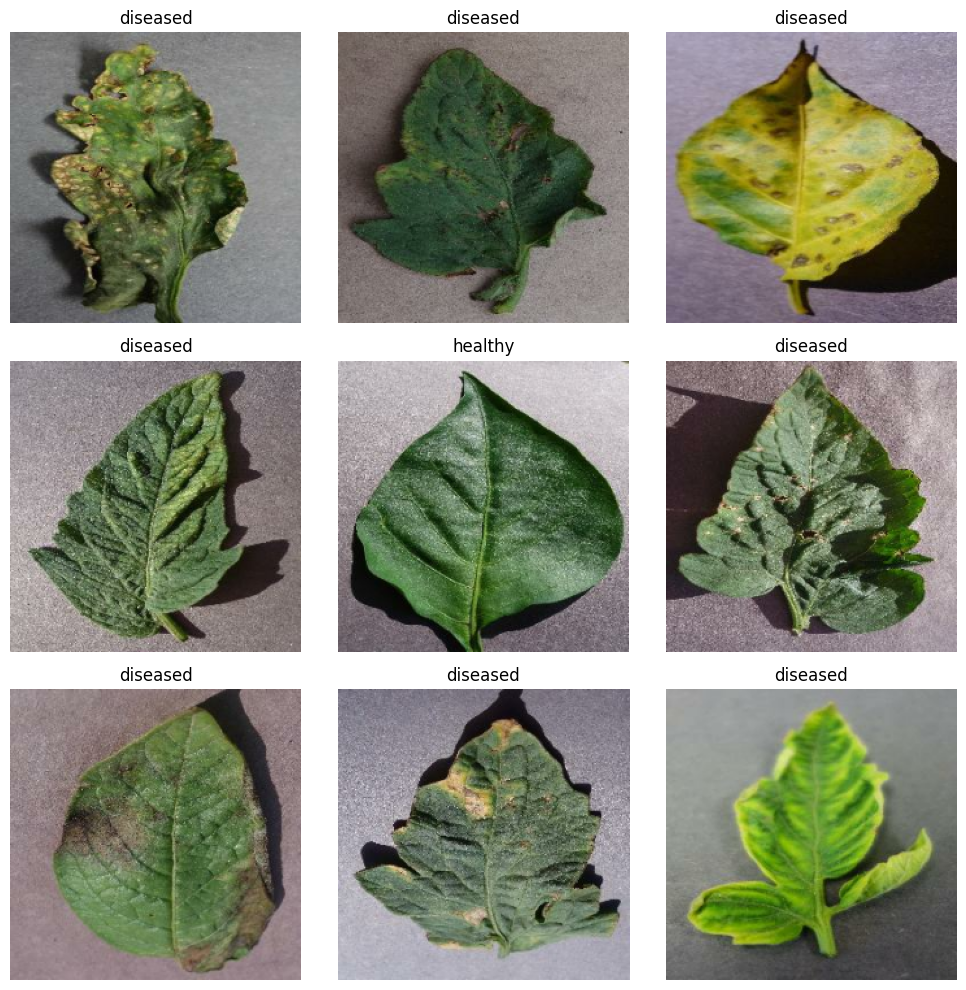

In [4]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label = labels[i].numpy()
        plt.title("healthy" if label == 0 else "diseased")
        plt.axis("off")
    plt.tight_layout()


In [5]:
import os
from collections import Counter

base_path = "dataset/train"
counts = Counter([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])

for cls, count in counts.items():
    print(f"{cls:40s}  {count} Bilder")


Tomato_healthy                            1 Bilder
Potato___Early_blight                     1 Bilder
PlantVillage                              1 Bilder
Tomato__Tomato_YellowLeaf__Curl_Virus     1 Bilder
Tomato_Early_blight                       1 Bilder
Tomato__Target_Spot                       1 Bilder
Potato___Late_blight                      1 Bilder
Tomato_Leaf_Mold                          1 Bilder
Tomato_Spider_mites_Two_spotted_spider_mite  1 Bilder
Tomato_Septoria_leaf_spot                 1 Bilder
Tomato__Tomato_mosaic_virus               1 Bilder
Pepper__bell___Bacterial_spot             1 Bilder
Tomato_Bacterial_spot                     1 Bilder
Tomato_Late_blight                        1 Bilder
Pepper__bell___healthy                    1 Bilder
Potato___healthy                          1 Bilder


Found 3109 files belonging to 16 classes.


2025-11-04 17:19:58.299419: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [3109]
	 [[{{node Placeholder/_4}}]]
2025-11-04 17:19:58.299741: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3109]
	 [[{{node Placeholder/_0}}]]


1/1 [==============================] - 0s 158ms/step


2025-11-04 17:19:58.525391: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 0s 216ms/step


2025-11-04 17:20:04.783308: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


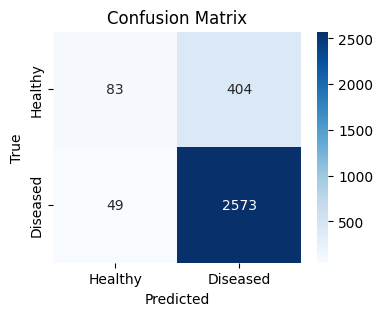

              precision    recall  f1-score   support

     Healthy       0.63      0.17      0.27       487
    Diseased       0.86      0.98      0.92      2622

    accuracy                           0.85      3109
   macro avg       0.75      0.58      0.59      3109
weighted avg       0.83      0.85      0.82      3109



In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Testdaten laden
test_dir = pathlib.Path("dataset/test")
test_ds = preprocess_dataset(test_dir)  # gleiche Funktion wie beim Trainieren

# Vorhersagen
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.round(preds).flatten()  # 0 oder 1
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Diseased'],
            yticklabels=['Healthy', 'Diseased'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Klassifikationsbericht
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Diseased']))


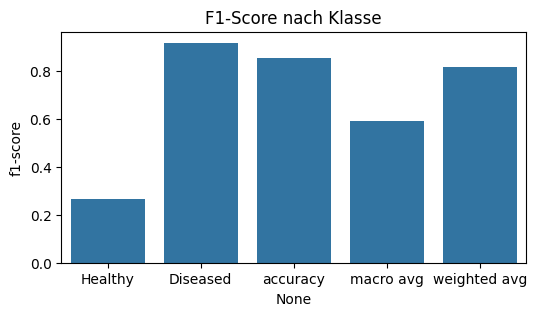

In [7]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

report = classification_report(y_true, y_pred, target_names=['Healthy', 'Diseased'], output_dict=True)
df = pd.DataFrame(report).transpose()

plt.figure(figsize=(6,3))
sns.barplot(x=df.index, y='f1-score', data=df)
plt.title('F1-Score nach Klasse')
plt.show()


In [8]:
from tensorflow import keras

model = keras.models.load_model("cnn_plant_disease_binary.keras")  # oder dein Dateiname
IMG_SIZE = (224, 224)


1/1 [==============================] - 0s 18ms/step


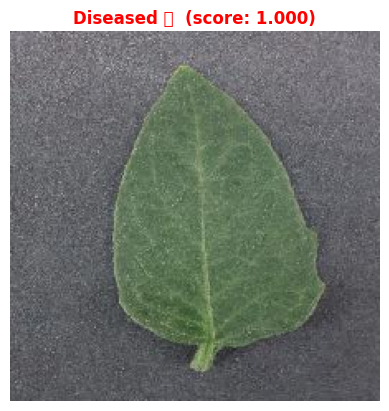

Rohwert (Sigmoid): 1.0000
Schwellenwert: 0.4
Vorhersage: Diseased 🌿


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

IMG_SIZE = (224, 224)

def predict_image(img_path):
    # Bild laden und vorbereiten
    img = keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = img_array / 255.0  # wie beim Training
    img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

    # Vorhersage
    pred = model.predict(img_array)[0][0]  # Ausgabewert des Sigmoid-Neurons (zwischen 0 und 1)

    # Threshold anpassen (Standard war 0.5)
    THRESH = 0.4   # bei < 0.5 ist das Modell oft zu "vorsichtig"
    label = "Diseased 🌿" if pred > THRESH else "Healthy 🍃"

    # Farbe für Titel wählen
    color = "red" if label.startswith("Diseased") else "green"

    # Bild + Ergebnis anzeigen
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{label}  (score: {pred:.3f})", color=color, fontsize=12, weight="bold")
    plt.show()

    # Rohwert und Entscheidung ausgeben
    print(f"Rohwert (Sigmoid): {pred:.4f}")
    print(f"Schwellenwert: {THRESH}")
    print("Vorhersage:", label)

# Beispielaufruf mit neuem Threshold
predict_image("dataset/test/Tomato_healthy/0d259481-e08d-459d-aa92-fe05e1524742___GH_HL Leaf 253.1.JPG")


In [10]:
import os

test_dir = "dataset/test/Tomato_healthy"
print(os.listdir(test_dir)[:20])


['e2991a66-412d-4841-8dc0-524e38338a82___GH_HL Leaf 517.1.JPG', 'ab1658d8-ef48-4068-b2b5-ce49fb3d06c0___GH_HL Leaf 397.1.JPG', 'da7db6e5-d5d5-489a-b1b2-9b3a880cebaa___RS_HL 9769.JPG', '2a1dd125-ece3-499f-a24b-1d00dbcc3184___GH_HL Leaf 227.JPG', 'f1e20811-da4e-4f0f-b8ee-f325d90f6481___RS_HL 0084.JPG', '139d2f99-d25b-440d-805e-d070a399d8f1___RS_HL 0600.JPG', '824ae544-73d2-448a-b442-a8d2cdd83922___RS_HL 9900.JPG', '57cc95ac-1fae-4959-ba16-d65c3db753d1___RS_HL 0312.JPG', 'b5142952-d782-4b4a-bf1b-db96da849191___RS_HL 0081.JPG', 'd2ce7896-6fa4-45e6-96c5-d162da0e3e1c___GH_HL Leaf 220.JPG', '47d38fb3-c397-433f-a478-482a660b70f3___RS_HL 0113.JPG', 'ef21da16-050f-4be8-a91f-e1fa13ce3991___RS_HL 0242.JPG', 'b842ca3c-1910-4ff3-8691-c7759830651a___RS_HL 9784.JPG', '9582a64b-e8a3-476f-9127-af5b45b0d833___RS_HL 0121.JPG', '43f6d6f0-be8e-4120-8c86-fad3bcfd5c03___RS_HL 0180.JPG', 'cb4a744a-1f1d-4cb1-b2a4-f1e1a12426ca___RS_HL 9970.JPG', '67549f03-2c86-44b7-9730-32d4a23287f3___GH_HL Leaf 495.2.JPG', '0e1